In [33]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

In [34]:
train_folder_path = "./data/X_train/"
train_df = pd.read_csv(train_folder_path + "clinical_train.csv", sep=",")

target_df = pd.read_csv(train_folder_path + "target_train.csv", sep=",")
target_df["OS_YEARS"] = pd.to_numeric(target_df["OS_YEARS"], errors="coerce")
target_df["OS_STATUS"] = target_df["OS_STATUS"].astype(bool)


molecular_train_df = pd.read_csv(train_folder_path + "molecular_train.csv", sep=",")


## Exploration des données


In [35]:
# train_folder_path = "./data/X_train/"
# train_df = pd.read_csv(train_folder_path + "clinical_train.csv", sep=",")
# print(train_df.count())
# target_df = pd.read_csv(train_folder_path + "target_train.csv", sep=",")
# target_df["OS_YEARS"] = pd.to_numeric(target_df["OS_YEARS"], errors="coerce")
# target_df["OS_STATUS"] = target_df["OS_STATUS"].astype(bool)
# train_df = train_df.loc[train_df['ID'].isin(target_df["ID"])]
# molecular_train_df = pd.read_csv(train_folder_path + "molecular_train.csv", sep=",")
# print(train_df.count())

In [36]:
train_df.head()

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"


In [37]:
train_df.describe()

,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT
count,3214.000000,3051.000000,3130.000000,2722.000000,3213.000000,3199.000000
mean,5.982545,6.535164,3.264735,0.955868,9.893549,167.048900
std,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031
min,0.000000,0.200000,0.000000,0.000000,4.000000,2.000000
25%,1.000000,2.700000,1.000000,0.150000,8.500000,65.500000
50%,3.000000,4.100000,2.000000,0.370000,9.700000,123.000000
75%,8.000000,6.655000,3.690000,0.783000,11.200000,229.500000
max,91.000000,154.400000,109.620000,44.200000,16.600000,1451.000000


In [38]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            3323 non-null   object 
 1   CENTER        3323 non-null   object 
 2   BM_BLAST      3214 non-null   float64
 3   WBC           3051 non-null   float64
 4   ANC           3130 non-null   float64
 5   MONOCYTES     2722 non-null   float64
 6   HB            3213 non-null   float64
 7   PLT           3199 non-null   float64
 8   CYTOGENETICS  2936 non-null   object 
dtypes: float64(6), object(3)
memory usage: 233.8+ KB


In [39]:
train_df.isnull().any()

ID              False
CENTER          False
BM_BLAST         True
WBC              True
ANC              True
MONOCYTES        True
HB               True
PLT              True
CYTOGENETICS     True
dtype: bool

In [40]:
train_df.loc[train_df["CYTOGENETICS"] == "46,xy"]

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
149,P117423,CCH,8.0,4.13,1.94,0.08,8.40,133.0,"46,xy"
150,P117424,CCH,18.0,4.54,1.95,0.27,13.30,102.0,"46,xy"
167,P117444,CCH,3.0,4.40,2.97,0.45,10.70,84.0,"46,xy"
169,P117446,CCH,6.0,4.27,1.78,1.17,12.10,69.0,"46,xy"
176,P117454,CCH,2.0,7.90,5.20,0.86,9.40,454.0,"46,xy"
...,...,...,...,...,...,...,...,...,...
3067,P131486,TUD,7.5,1.70,0.77,0.03,9.92,35.0,"46,xy"
3083,P131503,TUD,NaN,4.06,1.03,0.88,14.72,61.0,"46,xy"
3098,P131518,TUD,8.0,1.11,0.20,0.02,8.32,51.0,"46,xy"
3116,P131537,TUD,4.0,2.76,1.27,0.61,7.36,214.0,"46,xy"


In [41]:
target_df.describe()

,OS_YEARS
count,3173.000000
mean,2.480713
std,2.588259
min,0.000000
25%,0.652055
50%,1.652055
75%,3.572603
max,22.043836


In [42]:
target_df.loc[target_df["OS_STATUS"] == True].describe()

,OS_YEARS
count,1600.000000
mean,2.033873
std,2.061487
min,0.002740
25%,0.669863
50%,1.380822
75%,2.670548
max,17.375342


In [43]:
target_df.loc[target_df["OS_STATUS"] == False].describe()

,OS_YEARS
count,1573.000000
mean,2.935222
std,2.963922
min,0.000000
25%,0.632877
50%,2.268493
75%,4.221918
max,22.043836


In [44]:
target_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3323 entries, 0 to 3322
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         3323 non-null   object 
 1   OS_YEARS   3173 non-null   float64
 2   OS_STATUS  3323 non-null   bool   
dtypes: bool(1), float64(1), object(1)
memory usage: 55.3+ KB


In [45]:
target_df.isnull().any()

ID           False
OS_YEARS      True
OS_STATUS    False
dtype: bool

In [46]:
target_df = target_df.dropna(subset=["OS_YEARS"])
target_df.isnull().any()

ID           False
OS_YEARS     False
OS_STATUS    False
dtype: bool

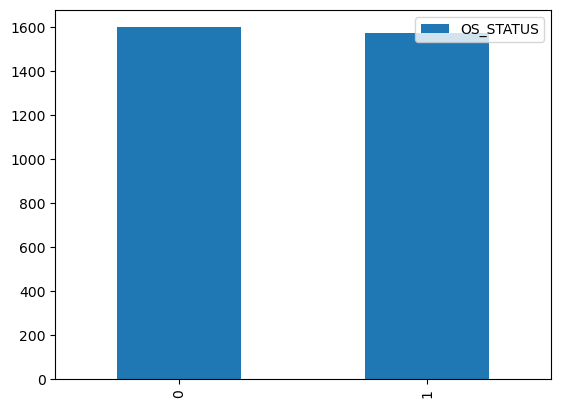

In [47]:
x = target_df["OS_STATUS"].value_counts().reset_index()
x.plot.bar()
plt.show()

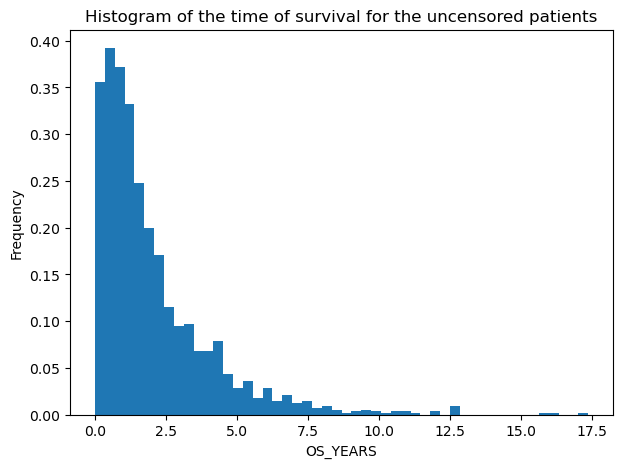

In [48]:
x = target_df.loc[target_df["OS_STATUS"] == True]["OS_YEARS"]
plt.figure(figsize=(7, 5))
plt.hist(x, bins=50, density=True)
plt.xlabel('OS_YEARS')
plt.ylabel('Frequency')
plt.title('Histogram of the time of survival for the uncensored patients')
plt.show()


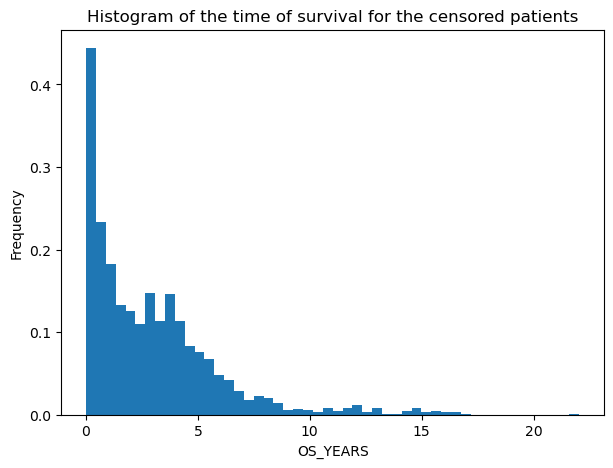

In [49]:
x = target_df.loc[target_df["OS_STATUS"] == False]["OS_YEARS"]
plt.figure(figsize=(7, 5))
plt.hist(x, bins=50, density=True)
plt.xlabel('OS_YEARS')
plt.ylabel('Frequency')
plt.title('Histogram of the time of survival for the censored patients')
plt.show()

In [50]:
nf = train_df.loc[train_df["CYTOGENETICS"] == "46,xx"]
nf_target = target_df.loc[target_df["ID"].isin(nf["ID"])]

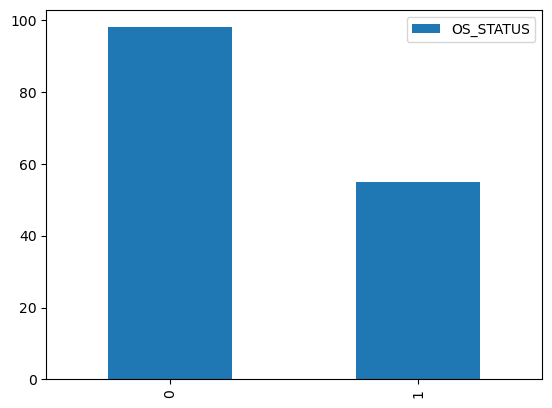

In [51]:
nf_target["OS_STATUS"].value_counts().reset_index().plot.bar()
plt.show()

In [52]:
nm = train_df.loc[train_df["CYTOGENETICS"] == "46,xy"]
nm_target = target_df.loc[target_df["ID"].isin(nf["ID"])]
nm_target = pd.concat((nm_target, nf_target)) 

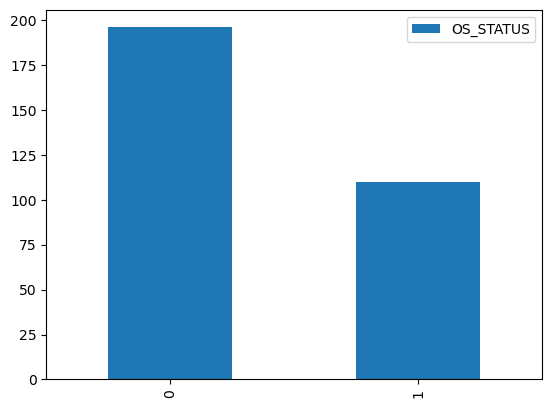

In [53]:
nm_target["OS_STATUS"].value_counts().reset_index().plot.bar()
plt.show()

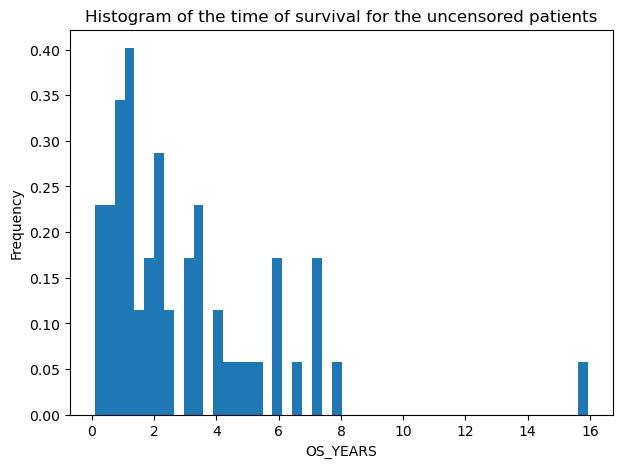

In [54]:
x = nm_target.loc[target_df["OS_STATUS"] == True]["OS_YEARS"]
plt.figure(figsize=(7, 5))
plt.hist(x, bins=50, density=True)
plt.xlabel('OS_YEARS')
plt.ylabel('Frequency')
plt.title('Histogram of the time of survival for the uncensored patients')
plt.show()


In [55]:
x.describe()

count    110.000000
mean       2.932055
std        2.773194
min        0.095890
25%        1.042466
50%        2.043836
75%        4.098630
max       15.939726
Name: OS_YEARS, dtype: float64

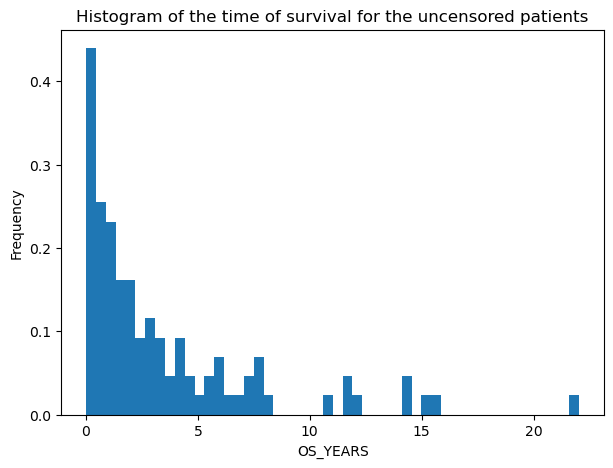

In [56]:
x = nm_target.loc[target_df["OS_STATUS"] == False]["OS_YEARS"]
plt.figure(figsize=(7, 5))
plt.hist(x, bins=50, density=True)
plt.xlabel('OS_YEARS')
plt.ylabel('Frequency')
plt.title('Histogram of the time of survival for the uncensored patients')
plt.show()

In [57]:
x.describe()

count    196.000000
mean       3.435141
std        4.171060
min        0.000000
25%        0.556164
50%        2.078082
75%        4.410959
max       22.043836
Name: OS_YEARS, dtype: float64

## Molecular

In [58]:
molecular_train_df.count()

ID                10935
CHR               10821
START             10821
END               10821
REF               10821
ALT               10821
GENE              10935
PROTEIN_CHANGE    10923
EFFECT            10935
VAF               10846
DEPTH             10821
dtype: int64

In [59]:
molecular_train_df.loc[molecular_train_df["START"] == 74732959.0]

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
116,P100164,17,74732959.0,74732962.0,G,GGGC,SRSF2,p.R94_P95insR,inframe_codon_gain,0.4954,694.0
126,P105745,17,74732959.0,74732962.0,G,GGGC,SRSF2,p.R94_P95insR,inframe_codon_gain,0.4516,1368.0
159,P120889,17,74732959.0,74732962.0,G,GGGC,SRSF2,p.R94_P95insR,inframe_codon_gain,0.6094,1966.0
220,P122305,17,74732959.0,74732962.0,G,GGGC,SRSF2,p.R94_P95insR,inframe_codon_gain,0.2778,1318.0
230,P122451,17,74732959.0,74732962.0,G,GGGC,SRSF2,p.R94_P95insR,inframe_codon_gain,0.4657,1470.0
...,...,...,...,...,...,...,...,...,...,...,...
10470,P117470,17,74732959.0,74732959.0,G,C,SRSF2,p.P95R,non_synonymous_codon,0.4150,494.0
10502,P117978,17,74732959.0,74732959.0,G,A,SRSF2,p.P95L,non_synonymous_codon,0.4820,1452.0
10509,P118014,17,74732959.0,74732959.0,G,T,SRSF2,p.P95H,non_synonymous_codon,0.4810,1446.0
10541,P120858,17,74732959.0,74732959.0,G,T,SRSF2,p.P95H,non_synonymous_codon,0.2620,933.0


In [60]:
molecular_train_df.loc[molecular_train_df["ID"] == "P132697"]

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH
4736,P132697,21,44514780.0,44514780.0,C,T,U2AF1,p.R156H,non_synonymous_codon,0.3500,2620.0
10146,P132697,2,25457242.0,25457242.0,C,T,DNMT3A,p.R882H,non_synonymous_codon,0.4220,1850.0
10398,P132697,13,28602341.0,28602341.0,T,G,FLT3,p.N676T,non_synonymous_codon,0.0910,2112.0
10399,P132697,13,28608329.0,28608329.0,A,G,FLT3,p.L576P,non_synonymous_codon,0.1400,1967.0
10400,P132697,16,30747705.0,30747707.0,T,TCC,SRCAP,p.V2306fs*2,frameshift_variant,0.1477,1339.0
10401,P132697,20,31022441.0,31022442.0,A,AG,ASXL1,p.G646fs*12,frameshift_variant,0.3553,906.0
10402,P132697,21,36164904.0,36164905.0,G,GC,RUNX1,p.A324fs*276,frameshift_variant,0.3342,458.0
10403,P132697,1,36932242.0,36932242.0,G,A,CSF3R,p.Q770*,stop_gained,0.0300,2771.0
10405,P132697,4,106190822.0,106190822.0,C,T,TET2,p.P1367L,non_synonymous_codon,0.3940,1351.0


In [61]:
#molecular_train_df.value_counts("CHR").reset_index()["count"]

In [62]:
chr_list = list(molecular_train_df.value_counts("CHR").reset_index()["CHR"])
new_df = train_df

In [63]:
# for chr in chr_list:
#     name = 'Nmut'+chr
#     tmp = molecular_train_df.loc[molecular_train_df["CHR"] == chr].groupby('ID').size().reset_index(name=name)
#     new_df = new_df.merge(tmp, on="ID", how="left").fillna({name: 0})

In [64]:
new_df["IS_MUTATION"] = (new_df["CYTOGENETICS"].isin(("46,xx", "46,xy")))
new_df = new_df.drop("CYTOGENETICS", axis=1)
new_df = new_df.drop("CENTER", axis=1)


In [65]:
X = new_df.loc[new_df['ID'].isin(target_df["ID"])]
X = X.drop("ID", axis=1)
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

imputer = SimpleImputer(strategy="median")
X_train[['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']] = imputer.fit_transform(X_train[['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']])
X_test[['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']] = imputer.transform(X_test[['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']])

In [66]:
X_train.dtypes

BM_BLAST       float64
WBC            float64
ANC            float64
MONOCYTES      float64
HB             float64
PLT            float64
IS_MUTATION       bool
dtype: object

In [67]:
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.67
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.66


## Prediction

In [68]:
features = ["BM_BLAST", "HB", "PLT"]
X = train_df.loc[train_df['ID'].isin(target_df["ID"]), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

In [69]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [70]:
# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[['BM_BLAST', 'HB', 'PLT']] = imputer.fit_transform(X_train[['BM_BLAST', 'HB', 'PLT']])
X_test[['BM_BLAST', 'HB', 'PLT']] = imputer.transform(X_test[['BM_BLAST', 'HB', 'PLT']])

In [71]:
# Import necessary libraries
import lightgbm as lgb
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

# Define LightGBM parameters
lgbm_params = {
    'max_depth': 3,
    'learning_rate': 0.05,
    'verbose': -1
}

# Prepare the data for LightGBM
# Scale the target (OS_YEARS) to reduce skew, apply weights based on event status
X_train_lgb = X_train  # Features for training
y_train_transformed = y_train['OS_YEARS']

# Create LightGBM dataset
train_dataset = lgb.Dataset(X_train_lgb, label=y_train_transformed)

# Train the LightGBM model
model = lgb.train(params=lgbm_params, train_set=train_dataset)

# Make predictions on the training and testing sets
pred_train = -model.predict(X_train)
pred_test = -model.predict(X_test)

# Evaluate the model using Concordance Index IPCW
train_ci_ipcw = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
test_ci_ipcw = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
print(f"LightGBM Survival Model Concordance Index IPCW on train: {train_ci_ipcw:.2f}")
print(f"LightGBM Survival Model Concordance Index IPCW on test: {test_ci_ipcw:.2f}")

LightGBM Survival Model Concordance Index IPCW on train: 0.69
LightGBM Survival Model Concordance Index IPCW on test: 0.65


ImportError: You must install graphviz and restart your session to plot tree.

<Figure size 2000x1000 with 0 Axes>

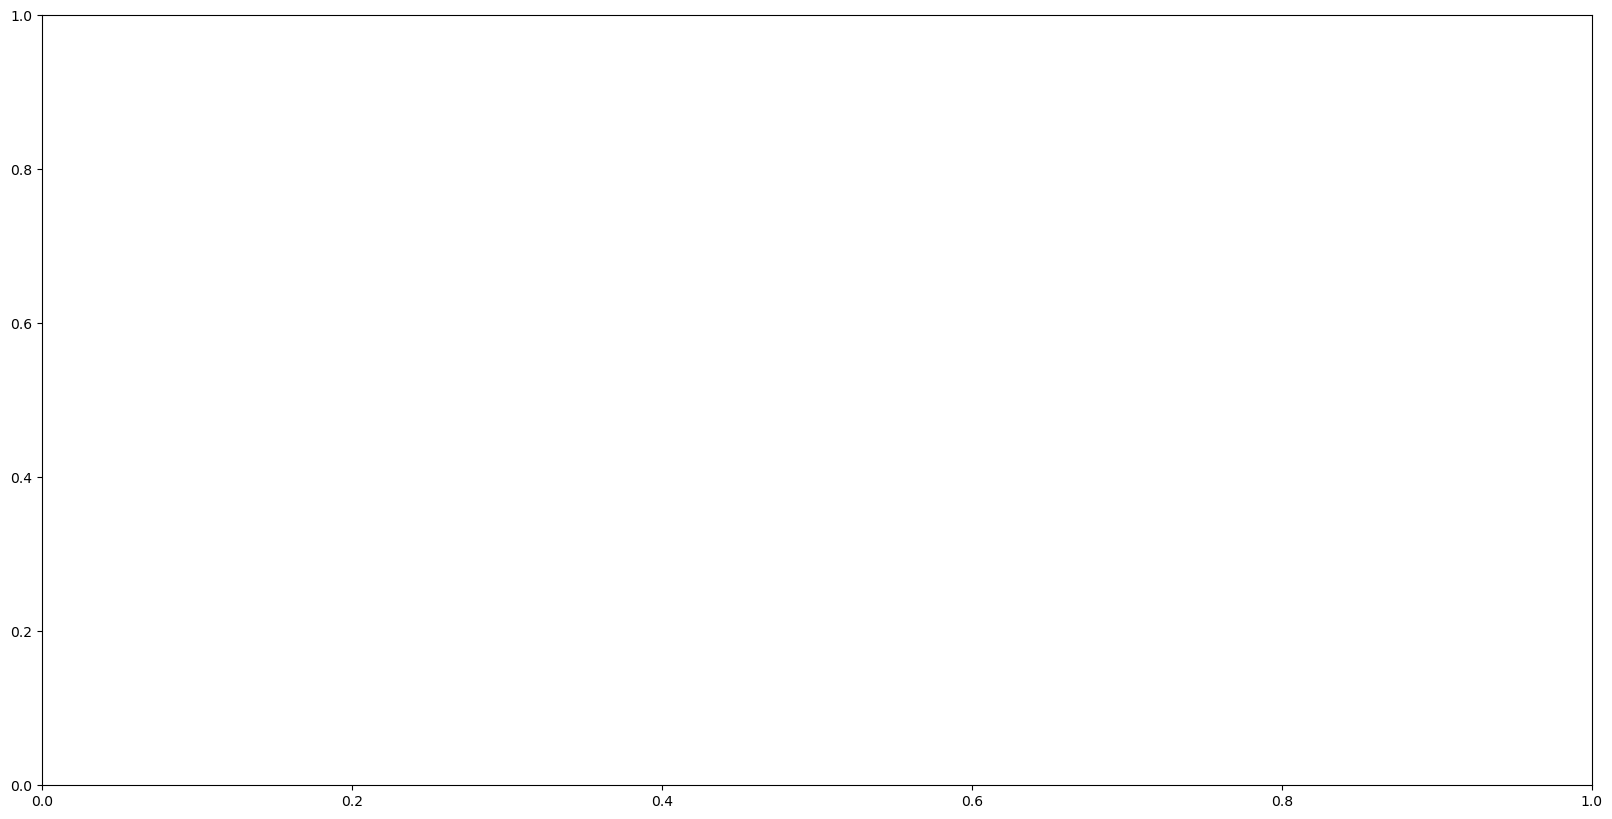

In [72]:
# Assuming the LightGBM model is defined as `model`
plt.figure(figsize=(20, 10))
lgb.plot_tree(model, tree_index=0, figsize=(20, 10), show_info=['split_gain', 'internal_value', 'internal_count', 'leaf_count'])
plt.title("First Tree in LightGBM Model")
plt.show()

In [73]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.66
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.66


In [74]:
# Step: Extract the number of somatic mutations per patient
# Group by 'ID' and count the number of mutations (rows) per patient
tmp = molecular_train_df.groupby('ID').size().reset_index(name='Nmut')

# Merge with the training dataset and replace missing values in 'Nmut' with 0
df_2 = train_df.merge(tmp, on='ID', how='left').fillna({'Nmut': 0})

In [83]:
# Select features
features = ['BM_BLAST', 'HB', 'PLT', 'ANC', 'MONOCYTES', 'Nmut']
target = ['OS_YEARS', 'OS_STATUS']

# Create the survival data format
X = df_2.loc[df_2['ID'].isin(target_df['ID']), features]
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

In [84]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [85]:
# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train[['BM_BLAST', 'HB', 'PLT', 'ANC', 'MONOCYTES', 'Nmut']] = imputer.fit_transform(X_train[['BM_BLAST', 'HB', 'PLT', 'ANC', 'MONOCYTES', 'Nmut']])
X_test[['BM_BLAST', 'HB', 'PLT', 'ANC', 'MONOCYTES', 'Nmut']] = imputer.transform(X_test[['BM_BLAST', 'HB', 'PLT', 'ANC', 'MONOCYTES', 'Nmut']])

In [86]:
# Initialize and train the Cox Proportional Hazards model
cox = CoxPHSurvivalAnalysis()
cox.fit(X_train, y_train)

# Evaluate the model using Concordance Index IPCW
cox_cindex_train = concordance_index_ipcw(y_train, y_train, cox.predict(X_train), tau=7)[0]
cox_cindex_test = concordance_index_ipcw(y_train, y_test, cox.predict(X_test), tau=7)[0]
print(f"Cox Proportional Hazard Model Concordance Index IPCW on train: {cox_cindex_train:.2f}")
print(f"Cox Proportional Hazard Model Concordance Index IPCW on test: {cox_cindex_test:.2f}")

Cox Proportional Hazard Model Concordance Index IPCW on train: 0.69
Cox Proportional Hazard Model Concordance Index IPCW on test: 0.68


**NEW PREDICTIONS**

In [87]:
features_new = ["BM_BLAST", "HB", "PLT"]
X_new = train_df.loc[train_df['ID'].isin(target_df["ID"]), features]
y_new = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

KeyError: "['Nmut'] not in index"

In [ ]:
# Split the data into training and testing sets
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.3, random_state=42)

In [ ]:
# Survival-aware imputation for missing values
imputer = SimpleImputer(strategy="median")
X_train_new[['BM_BLAST', 'HB', 'PLT']] = imputer.fit_transform(X_train_new[['BM_BLAST', 'HB', 'PLT']])
X_test_new[['BM_BLAST', 'HB', 'PLT']] = imputer.transform(X_test_new[['BM_BLAST', 'HB', 'PLT']])

# ===============================================
# 📘 Survival Analysis with Feature Selection 
# ===============================================

In [88]:
# --- Imports ---
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.impute import SimpleImputer
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv
import warnings
warnings.filterwarnings("ignore")


# ===============================================================
# 🔍 Evaluate impact of different feature subsets on C-index
# ===============================================================

In [89]:
from itertools import combinations
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv

results = []

# 🔹 Define base model (no cross-validation)
base_model = CoxnetSurvivalAnalysis()

# 🔹 Candidate features
all_features = ["BM_BLAST", "HB", "PLT", "ANC", "MONOCYTES"]

# ===============================================================
# Loop over all subsets of features (size 3 to len(all_features))
# ===============================================================
for k in range(3, len(all_features) + 1):
    for subset in combinations(all_features, k):
        subset = list(subset)

        # 🔹 Create subset of features and survival target
        X = train_df.loc[train_df['ID'].isin(target_df["ID"]), subset].copy()
        y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

        # 🔹 Handle missing values
        imputer = SimpleImputer(strategy="median")
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=subset)

        # 🔹 Split into training and test sets
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y, test_size=0.3, random_state=42
        )

        # 🔹 Fit model on training data
        model = base_model.fit(X_train, y_train)

        # 🔹 Predict risk scores on train/test
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

        # 🔹 Compute Concordance Index IPCW
        train_ci = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
        test_ci = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]

        # 🔹 Store results
        results.append({
            "Features": subset,
            "Train C-index": train_ci,
            "Test C-index": test_ci
        })

# ===============================================================
# Display results
# ===============================================================
results_df = (
    pd.DataFrame(results)
    .sort_values(by="Test C-index", ascending=False)
    .reset_index(drop=True)
)

print("✅ Top-performing feature subsets:")
display(results_df.head(10))



✅ Top-performing feature subsets:


,Features,Train C-index,Test C-index
0,"[BM_BLAST, HB, PLT, ANC]",0.666720,0.663586
1,"[BM_BLAST, HB, PLT, ANC, MONOCYTES]",0.666962,0.663525
2,"[BM_BLAST, HB, PLT, MONOCYTES]",0.665458,0.662149
3,"[BM_BLAST, HB, PLT]",0.663144,0.661103
4,"[BM_BLAST, HB, MONOCYTES]",0.642907,0.640129
5,"[BM_BLAST, HB, ANC, MONOCYTES]",0.643518,0.640091
6,"[BM_BLAST, HB, ANC]",0.643004,0.639710
7,"[BM_BLAST, PLT, ANC]",0.634065,0.635740
8,"[BM_BLAST, PLT, ANC, MONOCYTES]",0.634228,0.635504
9,"[BM_BLAST, PLT, MONOCYTES]",0.631578,0.633944


# ===============================================================
# 🧬 Clinical + Molecular Feature Evaluation for Survival Modeling
# ===============================================================

In [90]:
from itertools import combinations
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv

results = []

# ===============================================================
# 🔹 STEP 1 — Prepare Molecular Features
# ===============================================================

# Load molecular mutation data
molecular_train_df = pd.read_csv(train_folder_path + "molecular_train.csv", sep=",")

# Clean and simplify gene names
molecular_train_df = molecular_train_df.dropna(subset=["ID", "GENE"])
molecular_train_df["GENE"] = molecular_train_df["GENE"].str.upper().str.strip()

# Create binary gene matrix (1 if gene mutated)
mutation_matrix = (
    molecular_train_df.groupby(["ID", "GENE"]).size().unstack(fill_value=0)
)
mutation_matrix = (mutation_matrix > 0).astype(int)

# Add summary features (mean VAF, number of mutations)
agg_features = (
    molecular_train_df.groupby("ID")
    .agg(VAF_mean=("VAF", "mean"), num_mutations=("GENE", "count"))
)
molecular_features = mutation_matrix.join(agg_features, how="left").fillna(0)

# ===============================================================
# 🔹 STEP 2 — Merge Clinical + Molecular Data
# ===============================================================

# Merge molecular features with clinical data
merged_df = train_df.merge(molecular_features, on="ID", how="left").fillna(0)

# ===============================================================
# 🔹 STEP 3 — Define Candidate Features
# ===============================================================

# Clinical features
clinical_features = ["BM_BLAST", "HB", "PLT", "ANC", "MONOCYTES"]

# Keep only most frequent mutated genes to avoid overfitting (top 10)
top_genes = (
    molecular_train_df["GENE"]
    .value_counts()
    .head(10)
    .index.tolist()
)

# Combine features
all_features = clinical_features + top_genes + ["VAF_mean", "num_mutations"]

print("✅ Using features:", all_features)

# ===============================================================
# 🔹 STEP 4 — Loop over feature subsets and evaluate survival model
# ===============================================================

base_model = CoxnetSurvivalAnalysis()

for k in range(3, 8):
    for subset in combinations(all_features, k):
        subset = list(subset)

        # Select features and target
        X = merged_df.loc[merged_df['ID'].isin(target_df["ID"]), subset].copy()
        y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

        # Handle missing values
        imputer = SimpleImputer(strategy="median")
        X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=subset)

        # Train/Test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_imputed, y, test_size=0.3, random_state=42
        )

        # Fit Cox model
        model = base_model.fit(X_train, y_train)

        # Predict risk scores
        pred_train = model.predict(X_train)
        pred_test = model.predict(X_test)

        # Compute Concordance Index IPCW
        train_ci = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
        test_ci = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]

        # Store results
        results.append({
            "Features": subset,
            "Train C-index": train_ci,
            "Test C-index": test_ci
        })

# ===============================================================
# 🔹 STEP 5 — Display Results
# ===============================================================

results_df = (
    pd.DataFrame(results)
    .sort_values(by="Test C-index", ascending=False)
    .reset_index(drop=True)
)

print("✅ Top-performing feature subsets:")
display(results_df.head(10))


✅ Using features: ['BM_BLAST', 'HB', 'PLT', 'ANC', 'MONOCYTES', 'TET2', 'ASXL1', 'SF3B1', 'DNMT3A', 'RUNX1', 'SRSF2', 'TP53', 'STAG2', 'U2AF1', 'EZH2', 'VAF_mean', 'num_mutations']


KeyboardInterrupt: 

In [ ]:
print(results_df.loc[0, "Features"])

NameError: name 'results_df' is not defined

In [91]:
# ===============================================================
# 🔹 1. Define your selected features
# ===============================================================
selected_features = ['BM_BLAST', 'HB', 'PLT', 'ANC', 'TET2', 'TP53', 'num_mutations']

# 🔹 Prepare dataset (merged_df should already contain clinical + molecular data)
X = merged_df.loc[merged_df['ID'].isin(target_df["ID"]), selected_features].copy()
y = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_df)

# ===============================================================
# 🔹 2. Handle missing values
# ===============================================================
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=selected_features)

# ===============================================================
# 🔹 3. Train/test split
# ===============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.3, random_state=42
)

# ===============================================================
# 🔹 4. Define helper function for training + evaluation
# ===============================================================
def evaluate_model(X_train, X_test, y_train, y_test, normalize=False):
    """Train and evaluate Cox model, optionally normalizing features."""
    model = CoxnetSurvivalAnalysis()
    
    # Optionally normalize
    if normalize:
        scaler = StandardScaler()
        X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
        X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

    model.fit(X_train, y_train)
    
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)
    
    train_ci = concordance_index_ipcw(y_train, y_train, pred_train, tau=7)[0]
    test_ci = concordance_index_ipcw(y_train, y_test, pred_test, tau=7)[0]
    
    return train_ci, test_ci

# ===============================================================
# 🔹 5. Evaluate both raw and normalized versions
# ===============================================================
train_ci_raw, test_ci_raw = evaluate_model(X_train, X_test, y_train, y_test, normalize=False)
train_ci_norm, test_ci_norm = evaluate_model(X_train, X_test, y_train, y_test, normalize=True)

# ===============================================================
# 🔹 6. Display results
# ===============================================================
print("📊 Model performance comparison:")
print(f"Without normalization → Train C-index: {train_ci_raw:.3f}, Test C-index: {test_ci_raw:.3f}")
print(f"With normalization    → Train C-index: {train_ci_norm:.3f}, Test C-index: {test_ci_norm:.3f}")


NameError: name 'StandardScaler' is not defined

In [102]:
# ===============================================================
# ⚙️ Gradient Boosting Regressor (GBM) with Grid Search
# ===============================================================

import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

# ===============================================================
# 🔹 1. Select Features and Prepare Data
# ===============================================================

selected_features = ['BM_BLAST', 'HB', 'PLT', 'ANC', 'TET2', 'TP53', 'num_mutations']

# Merge dataset already contains clinical + molecular data
X = merged_df.loc[merged_df['ID'].isin(target_df["ID"]), selected_features].copy()
y_full = target_df[['OS_STATUS', 'OS_YEARS']].copy()

# Only keep uncensored patients for training the regressor
mask_uncensored = y_full['OS_STATUS'] == 1
X_uncensored = X[mask_uncensored]
y_uncensored = y_full.loc[mask_uncensored, 'OS_YEARS']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_uncensored, y_uncensored, test_size=0.3, random_state=42)

# Imputation + scaling
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=selected_features)
X_test = pd.DataFrame(imputer.transform(X_test), columns=selected_features)

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features)
X_test = pd.DataFrame(scaler.transform(X_test), columns=selected_features)

# ===============================================================
# 🔹 2. Define Model and Parameter Grid
# ===============================================================

gbm = GradientBoostingRegressor(loss='squared_error', random_state=42)
my_kfold = KFold(n_splits=5, shuffle=True, random_state=0)

param_grid = {
    "n_estimators": [100, 200, 300, 500, 1000, 1500, 2000],
    "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 8, 10],
    "min_samples_split": [2, 4, 8]
}

grid = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    cv=my_kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# ===============================================================
# 🔹 3. Run Grid Search
# ===============================================================

grid.fit(X_train, y_train)
print(f"✅ Best parameters: {grid.best_params_}")
print(f"✅ Best CV R²: {grid.best_score_:.3f}")

# ===============================================================
# 🔹 4. Evaluate on Survival Outcome (C-index)
# ===============================================================

# Predict for all patients (including censored)
X_all = pd.DataFrame(scaler.transform(imputer.transform(X)), columns=selected_features)
predicted_survival = grid.best_estimator_.predict(X_all)


# Structured survival arrays
y_struct_train = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_train)
y_struct_test = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_test)
y_struct = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_full)

# ===============================================================
# 5️⃣ Concordance Index Evaluation
# ===============================================================
# IPCW C-index (adjusted for censoring)
train_ci_ipcw = concordance_index_ipcw(y_struct_train, y_struct_train, -pred_train, tau=7)[0]
test_ci_ipcw = concordance_index_ipcw(y_struct_train, y_struct_test, -pred_test, tau=7)[0]



print(f"✅ XGBR Concordance Index IPCW (train): {train_ci_ipcw:.3f}")
print(f"✅ XGBR Concordance Index IPCW (test):  {test_ci_ipcw:.3f}")


Fitting 5 folds for each of 420 candidates, totalling 2100 fits
✅ Best parameters: {'learning_rate': 0.005, 'max_depth': 3, 'min_samples_split': 8, 'n_estimators': 500}
✅ Best CV R²: 0.139


TypeError: exepected pandas.DataFrame, but got <class 'pandas.core.series.Series'>

In [108]:
# ===============================================================
# ⚙️ Gradient Boosting Regressor (GBM) with Grid Search + C-index
# ===============================================================

import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw

# ===============================================================
# 1️⃣ Select Features and Prepare Data
# ===============================================================

selected_features = ['BM_BLAST', 'HB', 'PLT', 'ANC', 'TET2', 'TP53', 'num_mutations']

# Merge dataset already contains clinical + molecular data
X = merged_df.loc[merged_df['ID'].isin(target_df["ID"]), selected_features].copy()
y_full = target_df[['OS_STATUS', 'OS_YEARS']].copy()

# Keep uncensored patients for training
mask_uncensored = y_full['OS_STATUS'] == 1
X_uncensored = X[mask_uncensored]
y_uncensored = y_full.loc[mask_uncensored, 'OS_YEARS']

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_uncensored, y_uncensored, test_size=0.3, random_state=42
)

# Preprocess: impute + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(imputer.fit_transform(X_train)),
    columns=selected_features,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(imputer.transform(X_test)),
    columns=selected_features,
    index=X_test.index
)

# ===============================================================
# 2️⃣ Define GBM Model + Parameter Grid
# ===============================================================

gbm = GradientBoostingRegressor(loss='squared_error', random_state=42)
my_kfold = KFold(n_splits=5, shuffle=True, random_state=0)

param_grid = {
    "n_estimators": [200, 500, 1000, 1500],
    "learning_rate": [0.005, 0.01, 0.05, 0.1],
    "max_depth": [3, 5, 8],
    "min_samples_split": [2, 4, 8]
}

grid = GridSearchCV(
    estimator=gbm,
    param_grid=param_grid,
    cv=my_kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# ===============================================================
# 3️⃣ Run Grid Search
# ===============================================================

grid.fit(X_train_scaled, y_train)

print("✅ Best Parameters:", grid.best_params_)
print(f"✅ Best CV R²: {grid.best_score_:.3f}")

# ===============================================================
# 4️⃣ Evaluate Model on Survival Outcome (C-index)
# ===============================================================

# Predict survival times
pred_train = grid.best_estimator_.predict(X_train_scaled)
pred_test = grid.best_estimator_.predict(X_test_scaled)

# Predict for all patients (including censored)
X_all = pd.DataFrame(
    scaler.transform(imputer.transform(X)),
    columns=selected_features,
    index=X.index
)
pred_all = grid.best_estimator_.predict(X_all)

# ===============================================================
# 5️⃣ Concordance Index Evaluation
# ===============================================================

# IPCW-adjusted C-index
train_ci_ipcw = concordance_index_ipcw(y_train, y_train, -pred_train, tau=7)[0]
test_ci_ipcw = concordance_index_ipcw(y_train, y_test, -pred_test, tau=7)[0]


# ===============================================================
# ✅ Results
# ===============================================================
print(f"✅ GBM Concordance Index IPCW (train): {train_ci_ipcw:.3f}")
print(f"✅ GBM Concordance Index IPCW (test):  {test_ci_ipcw:.3f}")


Fitting 5 folds for each of 144 candidates, totalling 720 fits


✅ Best Parameters: {'learning_rate': 0.005, 'max_depth': 3, 'min_samples_split': 8, 'n_estimators': 500}
✅ Best CV R²: 0.139


ValueError: y must be a structured array with the first field being a binary class event indicator and the second field the time of the event/censoring

In [ ]:
# ===============================================================
# ⚙️ XGboost with Grid Search
# ===============================================================

from xgboost import XGBRegressor

# ===============================================================
# 🔹 1. Select Features and Prepare Data
# ===============================================================

selected_features = ['BM_BLAST', 'HB', 'PLT', 'ANC', 'TET2', 'TP53', 'num_mutations']

# Merge dataset already contains clinical + molecular data
X = merged_df.loc[merged_df['ID'].isin(target_df["ID"]), selected_features].copy()
y_full = target_df[['OS_STATUS', 'OS_YEARS']].copy()

# Only keep uncensored patients for training the regressor
mask_uncensored = y_full['OS_STATUS'] == 1
X_uncensored = X[mask_uncensored]
y_uncensored = y_full.loc[mask_uncensored, 'OS_YEARS']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_uncensored, y_uncensored, test_size=0.3, random_state=42)

# Imputation + scaling
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=selected_features)
X_test = pd.DataFrame(imputer.transform(X_test), columns=selected_features)

# ===============================================================
# 🔹 2. Define Model and Parameter Grid
# ===============================================================

XGBR = XGBRegressor()
my_kfold = KFold(n_splits=5, shuffle=True, random_state=0)

param_grid = {
    "n_estimators": [100, 200, 300, 500, 1000, 1500, 2000],
    "learning_rate": [0.005, 0.01, 0.05, 0.1, 0.2],
    "reg_alpha": [0, 0.001, 0.01, 0.1, 1, 10],
    "reg_lambda": [0, 0.01, 0.1, 1, 5, 10],
    "max_depth": [3, 5, 8, 10]
}

grid = GridSearchCV(
    estimator=XGBR,
    param_grid=param_grid,
    cv=my_kfold,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# ===============================================================
# 🔹 3. Run Grid Search
# ===============================================================

grid.fit(X_train, y_train)
print(f"✅ Best parameters: {grid.best_params_}")
print(f"✅ Best CV R²: {grid.best_score_:.3f}")

# ===============================================================
# 🔹 4. Evaluate on Survival Outcome (C-index)
# ===============================================================

# Predict for all patients (including censored)
X_all = pd.DataFrame(scaler.transform(imputer.transform(X)), columns=selected_features)
predicted_survival = grid.best_estimator_.predict(X_all)

# Structured survival arrays
y_struct_train = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_train)
y_struct_test = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_test)

# ===============================================================
# 5️⃣ Concordance Index Evaluation
# ===============================================================
# IPCW C-index (adjusted for censoring)
train_ci_ipcw = concordance_index_ipcw(y_struct_train, y_struct_train, -pred_train, tau=7)[0]
test_ci_ipcw = concordance_index_ipcw(y_struct_train, y_struct_test, -pred_test, tau=7)[0]



print(f"✅ XGBR Concordance Index IPCW (train): {train_ci_ipcw:.3f}")
print(f"✅ XGBR Concordance Index IPCW (test):  {test_ci_ipcw:.3f}")

Fitting 5 folds for each of 5040 candidates, totalling 25200 fits


/home/diego/miniconda3/envs/DC/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/diego/miniconda3/envs/DC/lib/python3.10/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant

✅ Best parameters: {'learning_rate': 0.005, 'max_depth': 3, 'n_estimators': 1500, 'reg_alpha': 10, 'reg_lambda': 10}
✅ Best CV R²: 0.165
📈 Concordance Index (C-index): 0.730


In [101]:
# ===============================================================
# ⚙️ XGBoost Regressor for Survival Prediction (C-index Evaluation)
# ===============================================================

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored, concordance_index_ipcw

# ===============================================================
# 1️⃣ Select features and target
# ===============================================================
features = ['BM_BLAST', 'HB', 'PLT', 'ANC', 'TET2', 'TP53', 'num_mutations', 'Nmut']

# Merge molecular and clinical data
merged_df2 = df_2.merge(molecular_features, on="ID", how="left").fillna(0)
X = merged_df2.loc[merged_df2['ID'].isin(target_df['ID']), features + ['ID']].copy()
y_full = target_df[['ID', 'OS_STATUS', 'OS_YEARS']].copy()

# Align indices
X = X.set_index("ID")
y_full = y_full.set_index("ID")
X = X.loc[y_full.index]

# ===============================================================
# 2️⃣ Split train/test and preprocess
# ===============================================================
X_train, X_test, y_train_df, y_test_df = train_test_split(
    X, y_full, test_size=0.3, random_state=42
)

# Impute missing + scale
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(imputer.fit_transform(X_train)), columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(imputer.transform(X_test)), columns=features, index=X_test.index)

# ===============================================================
# 3️⃣ Define and train XGBoost Regressor (on survival times)
# ===============================================================
XGBR = XGBRegressor(
    learning_rate=0.005,
    max_depth=3,
    n_estimators=1500,
    reg_alpha=10,
    reg_lambda=10,
    random_state=42,
    n_jobs=-1
)

# Train only on uncensored data (where OS_STATUS == 1)
mask_train_uncensored = y_train_df["OS_STATUS"] == 1
XGBR.fit(X_train_scaled[mask_train_uncensored], y_train_df.loc[mask_train_uncensored, "OS_YEARS"])

# ===============================================================
# 4️⃣ Evaluate predictions
# ===============================================================
pred_train = XGBR.predict(X_train_scaled)
pred_test = XGBR.predict(X_test_scaled)
pred_all = XGBR.predict(pd.DataFrame(scaler.transform(imputer.transform(X)), columns=features, index=X.index))

# Structured survival arrays
y_struct_train = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_train_df)
y_struct_test = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_test_df)
y_struct_full = Surv.from_dataframe("OS_STATUS", "OS_YEARS", y_full)

# ===============================================================
# 5️⃣ Concordance Index Evaluation
# ===============================================================
# IPCW C-index (adjusted for censoring)
train_ci_ipcw = concordance_index_ipcw(y_struct_train, y_struct_train, -pred_train, tau=7)[0]
test_ci_ipcw = concordance_index_ipcw(y_struct_train, y_struct_test, -pred_test, tau=7)[0]

# Standard (unweighted) C-index
c_index = concordance_index_censored(
    y_struct_full["OS_STATUS"],
    y_struct_full["OS_YEARS"],
    -pred_all
)[0]

# ===============================================================
# ✅ Display results
# ===============================================================
print(f"✅ XGBR Concordance Index IPCW (train): {train_ci_ipcw:.3f}")
print(f"✅ XGBR Concordance Index IPCW (test):  {test_ci_ipcw:.3f}")
print(f"📈 Standard Concordance Index (overall): {c_index:.3f}")
print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")




✅ XGBR Concordance Index IPCW (train): 0.707
✅ XGBR Concordance Index IPCW (test):  0.688
📈 Standard Concordance Index (overall): 0.734
Train samples: 2221, Test samples: 952
